In [2]:
import numpy as np
import pandas as pd
import os
os.chdir(r'G:\My Drive\result\publication\cellreport\revision')

In [6]:
ref = pd.read_csv('13059_2020_2210_MOESM4_ESM.csv',index_col = 0,skiprows=[0])
ref

,contig_id,high_confidence,length,chain,v_gene,d_gene,j_gene,c_gene,full_length,productive,cdr3,cdr3_nt,reads,umis,raw_clonotype_id,raw_consensus_id,tissue,cell_barcode,cell type
1,AAACCTGAGCCACGCT-16_contig_1,True,499,TRA,TRAV13-2,NaN,TRAJ4,TRAC,True,True,CAEKLFPNKLIF,TGTGCAGAGAAGTTGTTCCCCAATAAGCTGATTTTT,1198,2,clonotype221,clonotype221_consensus_1,Spleen,Spleen_cDNA_AAACCTGAGCCACGCT-1,MT1E_TEFF
2,AAACCTGAGCCACGCT-16_contig_2,True,500,TRB,TRBV10-1,NaN,TRBJ2-2,TRBC2,True,True,CASSDLTSGGELFF,TGCGCCAGCAGTGACCTGACTAGCGGAGGGGAGCTGTTTTTT,4526,1,clonotype221,clonotype221_consensus_2,Spleen,Spleen_cDNA_AAACCTGAGCCACGCT-1,MT1E_TEFF
3,AAACCTGAGCCACGCT-16_contig_3,True,309,TRB,NaN,NaN,TRBJ2-5,TRBC2,False,False,NaN,NaN,1146,3,clonotype221,NaN,Spleen,Spleen_cDNA_AAACCTGAGCCACGCT-1,MT1E_TEFF
4,AAACCTGAGCTACCGC-10_contig_1,True,526,TRA,TRAV14/DV4,NaN,TRAJ3,TRAC,True,True,CAMREEYSSASKIIF,TGTGCAATGAGAGAGGAGTACAGCAGTGCTTCCAAGATAATCTTT,1726,2,clonotype483,clonotype483_consensus_1,Lymph.node,Lymph.node_cDNA_AAACCTGAGCTACCGC-1,GZMK_TEM
5,AAACCTGAGCTACCGC-10_contig_2,True,476,TRB,TRBV9,NaN,TRBJ2-5,TRBC2,True,True,CASSGGQGAGETQYF,TGTGCCAGCAGCGGGGGACAGGGGGCAGGGGAGACCCAGTACTTC,4386,3,clonotype483,clonotype483_consensus_2,Lymph.node,Lymph.node_cDNA_AAACCTGAGCTACCGC-1,GZMK_TEM
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12149,TTTGTCATCGGCCGAT-15_contig_2,True,507,TRB,TRBV12-4,NaN,TRBJ2-2,TRBC2,True,True,CASREAGGVTGELFF,TGTGCCAGCAGGGAAGCGGGAGGGGTCACCGGGGAGCTGTTTTTT,5616,3,clonotype11689,clonotype11689_consensus_3,Small.intestine,Small.intestine_cDNA_TTTGTCATCGGCCGAT-1,GZMB_TRM
12150,TTTGTCATCGGCCGAT-15_contig_3,True,610,TRA,TRAV41,NaN,TRAJ49,TRAC,True,True,CAVRSGSGNQFYF,TGTGCTGTCAGATCGGGTTCCGGTAACCAGTTCTATTTT,5210,2,clonotype11689,clonotype11689_consensus_1,Small.intestine,Small.intestine_cDNA_TTTGTCATCGGCCGAT-1,GZMB_TRM
12151,TTTGTCATCGGCCGAT-15_contig_4,True,484,TRA,NaN,NaN,TRAJ39,TRAC,False,False,NaN,NaN,3112,1,clonotype11689,NaN,Small.intestine,Small.intestine_cDNA_TTTGTCATCGGCCGAT-1,GZMB_TRM
12152,TTTGTCATCTCTAGGA-19_contig_1,True,527,TRB,TRBV20-1,NaN,TRBJ2-1,TRBC2,True,True,CSAREPGTSVDNEQFF,TGCAGTGCTAGAGAGCCCGGGACTAGCGTTGACAATGAGCAGTTCTTC,4212,7,clonotype287,clonotype287_consensus_1,Trachea,Trachea_cDNA_TTTGTCATCTCTAGGA-1,PRR4_TRM


In [35]:
filtered_ref = ref[(ref['productive']==True) & (ref['tissue']=='Liver') & (ref['chain']=='TRA')]
filtered_ref = filtered_ref.drop_duplicates(subset = 'cell_barcode',keep = 'first')
top_clones = filtered_ref['raw_clonotype_id'].value_counts().sort_values(ascending= False)[0:round(len(set(filtered_ref['raw_clonotype_id']))*0.1)].index

In [36]:
top_clones_ref = filtered_ref[filtered_ref['raw_clonotype_id'].isin(top_clones)]
top_clones_ref

,contig_id,high_confidence,length,chain,v_gene,d_gene,j_gene,c_gene,full_length,productive,cdr3,cdr3_nt,reads,umis,raw_clonotype_id,raw_consensus_id,tissue,cell_barcode,cell type
8,AAACCTGCAATCTACG-8_contig_2,True,571,TRA,TRAV29/DV5,NaN,TRAJ49,TRAC,True,True,CAASVMHTGNQFYF,TGTGCAGCAAGCGTTATGCACACCGGTAACCAGTTCTATTTT,26384,4,clonotype1,clonotype1_consensus_2,Liver,Liver_cDNA_AAACCTGCAATCTACG-1,INFG_TEM
85,AAAGCAACATGAGCGA-8_contig_2,True,514,TRA,TRAV29/DV5,NaN,TRAJ49,TRAC,True,True,CAASVMHTGNQFYF,TGTGCAGCAAGCGTTATGCACACCGGTAACCAGTTCTATTTT,6748,3,clonotype1,clonotype1_consensus_2,Liver,Liver_cDNA_AAAGCAACATGAGCGA-1,TRBV4-2_TEFF
162,AACACGTTCGCCAAAT-8_contig_2,True,514,TRA,TRAV29/DV5,NaN,TRAJ49,TRAC,True,True,CAASVMHTGNQFYF,TGTGCAGCAAGCGTTATGCACACCGGTAACCAGTTCTATTTT,25000,5,clonotype1,clonotype1_consensus_2,Liver,Liver_cDNA_AACACGTTCGCCAAAT-1,TYMS_TRM
212,AACGTTGTCGGTCCGA-8_contig_2,True,558,TRA,TRAV12-1,NaN,TRAJ39,TRAC,True,True,CVVLPNAGNMLTF,TGTGTGGTTCTGCCTAATGCAGGCAACATGCTCACCTTT,56602,5,clonotype95,clonotype95_consensus_2,Liver,Liver_cDNA_AACGTTGTCGGTCCGA-1,INFG_TEM
299,AACTCTTTCACAATGC-8_contig_2,True,465,TRA,TRAV29/DV5,NaN,TRAJ49,TRAC,True,True,CAASVMHTGNQFYF,TGTGCAGCAAGCGTTATGCACACCGGTAACCAGTTCTATTTT,6002,2,clonotype1,clonotype1_consensus_2,Liver,Liver_cDNA_AACTCTTTCACAATGC-1,TRBV4-2_TEFF
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11655,TTCGAAGCATATGCTG-8_contig_2,True,514,TRA,TRAV29/DV5,NaN,TRAJ49,TRAC,True,True,CAASVMHTGNQFYF,TGTGCAGCAAGCGTTATGCACACCGGTAACCAGTTCTATTTT,8944,1,clonotype1,clonotype1_consensus_2,Liver,Liver_cDNA_TTCGAAGCATATGCTG-1,TRBV4-2_TEFF
11697,TTCGGTCGTGTGACGA-8_contig_2,True,481,TRA,TRAV22,NaN,TRAJ58,TRAC,True,True,CAIEETSGSRLTF,TGTGCTATTGAAGAAACCAGTGGCTCTAGGTTGACCTTT,21870,4,clonotype13,clonotype13_consensus_2,Liver,Liver_cDNA_TTCGGTCGTGTGACGA-1,TYMS_TRM
11748,TTCTCAAGTTTAAGCC-8_contig_1,True,511,TRA,TRAV1-2,NaN,TRAJ42,TRAC,True,True,CAVRARGSQGNLIF,TGTGCTGTGAGAGCTCGAGGAAGCCAAGGAAATCTCATCTTT,10196,1,clonotype77,clonotype77_consensus_1,Liver,Liver_cDNA_TTCTCAAGTTTAAGCC-1,GIMAP4_TEM
11821,TTGAACGAGGGATGGG-8_contig_2,True,571,TRA,TRAV29/DV5,NaN,TRAJ49,TRAC,True,True,CAASVMHTGNQFYF,TGTGCAGCAAGCGTTATGCACACCGGTAACCAGTTCTATTTT,7062,1,clonotype1,clonotype1_consensus_2,Liver,Liver_cDNA_TTGAACGAGGGATGGG-1,INFG_TEM


<Axes: title={'center': 'TRAV usage of cells in the top 10 clones of liver CD8 T cells from PMID 33287869'}, ylabel='count'>

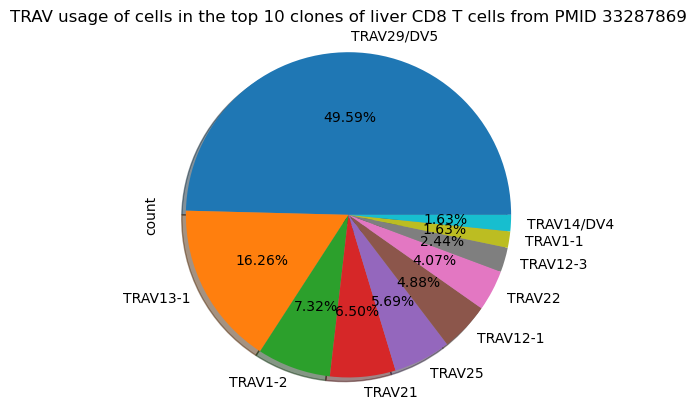

In [47]:
top_clones_ref['v_gene'].value_counts().plot.pie(autopct='%1.2f%%',
                                                 shadow=True, radius=1.1,
                                                 title = 'TRAV usage of cells in the top 10 clones of liver CD8 T cells from PMID 33287869')